In [1]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [2]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.duplicated().sum()

np.int64(31994)

In [5]:
duplicates = df[df.duplicated(keep=False)]
duplicates.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [7]:
df = df.drop_duplicates()
df.shape

(87396, 32)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,87396.0,0.274898,0.446466,0.00,0.0,0.0,1.0,1.0
lead_time,87396.0,79.891368,86.052325,0.00,11.0,49.0,125.0,737.0
arrival_date_year,87396.0,2016.210296,0.686102,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,87396.0,26.838334,13.674572,1.00,16.0,27.0,37.0,53.0
arrival_date_day_of_month,87396.0,15.815541,8.835146,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,87396.0,1.005263,1.031921,0.00,0.0,1.0,2.0,19.0
stays_in_week_nights,87396.0,2.625395,2.053584,0.00,1.0,2.0,4.0,50.0
adults,87396.0,1.875795,0.626500,0.00,2.0,2.0,2.0,55.0
children,87392.0,0.138640,0.455881,0.00,0.0,0.0,0.0,10.0
babies,87396.0,0.010824,0.113597,0.00,0.0,0.0,0.0,10.0


In [9]:
print("ADR <= 0:")
display(df[df["adr"] <= 0][["hotel", "adr", "is_canceled", "reservation_status"]])

print("Adults = 0:")
display(df[df["adults"] == 0][["hotel", "adults", "children", "babies", "adr"]])

print("Adults >= 10:")
display(df[df["adults"] >= 10][["hotel", "adults", "children", "babies", "adr"]])

print("Babies >= 5:")
display(df[df["babies"] >= 5][["hotel", "adults", "children", "babies", "adr"]])

ADR <= 0:


,hotel,adr,is_canceled,reservation_status
0,Resort Hotel,0.0,0,Check-Out
1,Resort Hotel,0.0,0,Check-Out
125,Resort Hotel,0.0,0,Check-Out
167,Resort Hotel,0.0,0,Check-Out
168,Resort Hotel,0.0,0,Check-Out
...,...,...,...,...
118631,City Hotel,0.0,0,Check-Out
118762,City Hotel,0.0,0,Check-Out
118963,City Hotel,0.0,0,Check-Out
119102,City Hotel,0.0,0,Check-Out


Adults = 0:


,hotel,adults,children,babies,adr
2224,Resort Hotel,0,0.0,0,0.00
2409,Resort Hotel,0,0.0,0,0.00
3181,Resort Hotel,0,0.0,0,0.00
3684,Resort Hotel,0,0.0,0,0.00
3708,Resort Hotel,0,0.0,0,0.00
...,...,...,...,...,...
117204,City Hotel,0,2.0,0,98.85
117274,City Hotel,0,2.0,0,93.64
117303,City Hotel,0,2.0,0,98.85
117453,City Hotel,0,2.0,0,121.88


Adults >= 10:


,hotel,adults,children,babies,adr
1539,Resort Hotel,40,0.0,0,0.0
1587,Resort Hotel,26,0.0,0,0.0
1643,Resort Hotel,50,0.0,0,0.0
1752,Resort Hotel,26,0.0,0,0.0
1884,Resort Hotel,26,0.0,0,0.0
1917,Resort Hotel,27,0.0,0,0.0
1962,Resort Hotel,27,0.0,0,0.0
2003,Resort Hotel,26,0.0,0,0.0
2164,Resort Hotel,26,0.0,0,0.0
2173,Resort Hotel,55,0.0,0,0.0


Babies >= 5:


,hotel,adults,children,babies,adr
46619,City Hotel,2,0.0,10,84.45
78656,City Hotel,1,0.0,9,95.00


In [11]:
df_adr = df[df["adr"] > 0].copy()

In [12]:
df[df["adults"] == 0][
    ["hotel", "adults", "children", "babies",
     "stays_in_weekend_nights", "stays_in_week_nights",
     "adr", "is_canceled"]
].describe()

,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,adr,is_canceled
count,385.0,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000
mean,0.0,1.155844,0.007792,1.145455,2.937662,50.920831,0.251948
std,0.0,1.026535,0.088043,1.737945,3.976004,49.125249,0.434696
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.0,2.000000,0.000000,1.000000,2.000000,65.660000,0.000000
75%,0.0,2.000000,0.000000,2.000000,4.000000,91.850000,1.000000
max,0.0,3.000000,1.000000,16.000000,41.000000,200.000000,1.000000


In [14]:
df_clean = df[df["adults"] > 0].copy()
df_clean.shape

(87011, 32)

In [15]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
company,81776
agent,12124
country,447
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [18]:
df_clean["company"] = df_clean["company"].fillna(0)
df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean["children"] = df_clean["children"].fillna(0)
df_clean.isnull().sum().sum()

np.int64(0)

In [19]:
df_clean.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [20]:
for col in ["hotel", "meal", "market_segment", "distribution_channel",
            "deposit_type", "customer_type", "reservation_status"]:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


hotel:
hotel
City Hotel      53055
Resort Hotel    33956
Name: count, dtype: int64

meal:
meal
BB           67694
SC            9389
HB            9076
Undefined      492
FB             360
Name: count, dtype: int64

market_segment:
market_segment
Online TA        51370
Offline TA/TO    13852
Direct           11751
Groups            4922
Corporate         4200
Complementary      688
Aviation           226
Undefined            2
Name: count, dtype: int64

distribution_channel:
distribution_channel
TA/TO        68842
Direct       12921
Corporate     5062
GDS            181
Undefined        5
Name: count, dtype: int64

deposit_type:
deposit_type
No Deposit    85866
Non Refund     1038
Refundable      107
Name: count, dtype: int64

customer_type:
customer_type
Transient          71726
Transient-Party    11611
Contract            3134
Group                540
Name: count, dtype: int64

reservation_status:
reservation_status
Check-Out    63083
Canceled     22918
No-Show       1010
Name: cou

In [21]:
df_clean["reservation_status_date"] = pd.to_datetime(
    df_clean["reservation_status_date"]
)

df_clean["reservation_status_date"].dtype

dtype('<M8[ns]')

In [23]:
df_clean["total_nights"] = (
    df_clean["stays_in_weekend_nights"] +
    df_clean["stays_in_week_nights"]
)

In [24]:
df_clean["total_guests"] = (
    df_clean["adults"] +
    df_clean["children"] +
    df_clean["babies"]
)

In [25]:
df_clean["total_stay_cost"] = (
    df_clean["adr"] * df_clean["total_nights"]
)


In [27]:
months = {
    "January": 1, "February": 2, "March": 3,
    "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9,
    "October": 10, "November": 11, "December": 12
}

df_clean["arrival_month_num"] = df_clean["arrival_date_month"].map(months)

df_clean["arrival_date"] = pd.to_datetime(
    df_clean["arrival_date_year"].astype(str) + "-" +
    df_clean["arrival_month_num"].astype(str) + "-" +
    df_clean["arrival_date_day_of_month"].astype(str)
)

In [30]:
df_clean["stay_type"] = pd.cut(
    df_clean["total_nights"],
    bins=[-1, 2, 7, float("inf")],
    labels=["Short", "Medium", "Long"]
)

In [29]:
df_clean[
    [
        "hotel",
        "arrival_date",
        "total_nights",
        "total_guests",
        "adr",
        "total_stay_cost",
        "stay_type"
    ]
].head(10)

,hotel,arrival_date,total_nights,total_guests,adr,total_stay_cost,stay_type
0,Resort Hotel,2015-07-01,0,2.0,0.0,0.0,Short
1,Resort Hotel,2015-07-01,0,2.0,0.0,0.0,Short
2,Resort Hotel,2015-07-01,1,1.0,75.0,75.0,Short
3,Resort Hotel,2015-07-01,1,1.0,75.0,75.0,Short
4,Resort Hotel,2015-07-01,2,2.0,98.0,196.0,Short
6,Resort Hotel,2015-07-01,2,2.0,107.0,214.0,Short
7,Resort Hotel,2015-07-01,2,2.0,103.0,206.0,Short
8,Resort Hotel,2015-07-01,3,2.0,82.0,246.0,Medium
9,Resort Hotel,2015-07-01,3,2.0,105.5,316.5,Medium
10,Resort Hotel,2015-07-01,4,2.0,123.0,492.0,Medium


In [31]:
monthly_bookings = (
    df_clean
    .groupby("arrival_month_num")
    .size()
    .reset_index(name="bookings")
)

monthly_bookings

,arrival_month_num,bookings
0,1,4667
1,2,6065
2,3,7473
3,4,7879
4,5,8329
5,6,7745
6,7,10011
7,8,11210
8,9,6671
9,10,6905


In [32]:
monthly_hotel = (
    df_clean
    .groupby(["arrival_month_num", "hotel"])
    .size()
    .reset_index(name="bookings")
)

monthly_hotel.head()

,arrival_month_num,hotel,bookings
0,1,City Hotel,2706
1,1,Resort Hotel,1961
2,2,City Hotel,3573
3,2,Resort Hotel,2492
4,3,City Hotel,4817


In [33]:
monthly_hotel.pivot(
    index="arrival_month_num",
    columns="hotel",
    values="bookings"
)

hotel,City Hotel,Resort Hotel
arrival_month_num,,
1,2706,1961
2,3573,2492
3,4817,2656
4,5051,2828
5,5387,2942
6,4986,2759
7,5698,4313
8,6544,4666
9,4221,2450


In [34]:
df_adr = df_clean[df_clean["adr"] > 0].copy()

In [35]:
monthly_adr = (
    df_adr
    .groupby(["arrival_month_num", "hotel"])["adr"]
    .mean()
    .reset_index()
)

monthly_adr

,arrival_month_num,hotel,adr
0,1,City Hotel,87.322725
1,1,Resort Hotel,50.654044
2,2,City Hotel,91.314238
3,2,Resort Hotel,55.255820
4,3,City Hotel,96.579065
5,3,Resort Hotel,58.856399
6,4,City Hotel,118.850295
7,4,Resort Hotel,80.856329
8,5,City Hotel,129.850437
9,5,Resort Hotel,82.285187


In [36]:
monthly_analysis = (
    df_adr
    .groupby(["arrival_month_num", "hotel"])
    .agg(
        bookings=("hotel", "size"),
        avg_adr=("adr", "mean")
    )
    .reset_index()
)

monthly_analysis

,arrival_month_num,hotel,bookings,avg_adr
0,1,City Hotel,2650,87.322725
1,1,Resort Hotel,1904,50.654044
2,2,City Hotel,3497,91.314238
3,2,Resort Hotel,2440,55.255820
4,3,City Hotel,4751,96.579065
5,3,Resort Hotel,2599,58.856399
6,4,City Hotel,4991,118.850295
7,4,Resort Hotel,2773,80.856329
8,5,City Hotel,5314,129.850437
9,5,Resort Hotel,2880,82.285187


In [37]:
monthly_analysis.groupby("hotel")[["bookings", "avg_adr"]].corr()

bookings   avg_adr
hotel                                    
City Hotel   bookings  1.000000  0.836418
             avg_adr   0.836418  1.000000
Resort Hotel bookings  1.000000  0.919838
             avg_adr   0.919838  1.000000

In [38]:
cancellation_rate = df_clean["is_canceled"].mean() * 100
cancellation_rate

np.float64(27.4999712680006)

In [39]:
hotel_cancellation = (
    df_clean
    .groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
)

hotel_cancellation

,is_canceled
hotel,
City Hotel,30.07
Resort Hotel,23.48


Cancellation rate отличается между двумя типами гостиниц: для City Hotel он составляет 30.07%, а для Resort Hotel — 23.48%. Разница составляет 6.59 процентных пункта.

In [41]:
df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, float("inf")],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181+ days"]
)

In [42]:
lead_time_analysis = (
    df_clean
    .groupby("lead_time_group", observed=True)
    .agg(
        bookings=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

lead_time_analysis["cancellation_rate"] = (
    lead_time_analysis["cancellation_rate"] * 100
).round(2)

lead_time_analysis

,lead_time_group,bookings,cancellation_rate
0,0-7 days,18185,8.41
1,8-30 days,16300,25.36
2,31-90 days,22666,32.05
3,91-180 days,18170,35.00
4,181+ days,11690,39.69


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

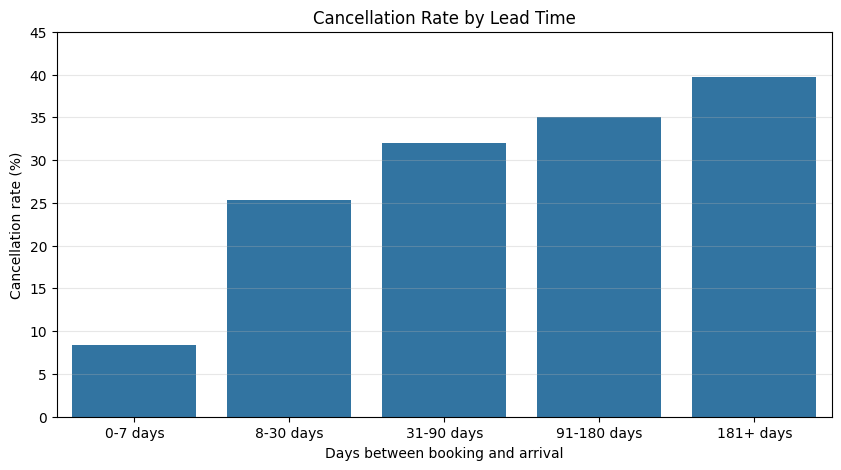

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=lead_time_analysis,
    x="lead_time_group",
    y="cancellation_rate"
)

plt.xlabel("Days between booking and arrival")
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation Rate by Lead Time")

plt.ylim(0, 45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [46]:
deposit_analysis = (
    df_clean
    .groupby("deposit_type")
    .agg(
        bookings=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

deposit_analysis["cancellation_rate"] = (
    deposit_analysis["cancellation_rate"] * 100
).round(2)

deposit_analysis

,deposit_type,bookings,cancellation_rate
0,No Deposit,85866,26.69
1,Non Refund,1038,94.70
2,Refundable,107,24.30


«В данных наблюдается очень высокая доля отмен среди бронирований с типом депозита Non Refund (94.70%). При этом данная категория значительно меньше No Deposit, поэтому результат следует интерпретировать с учётом размера группы.»

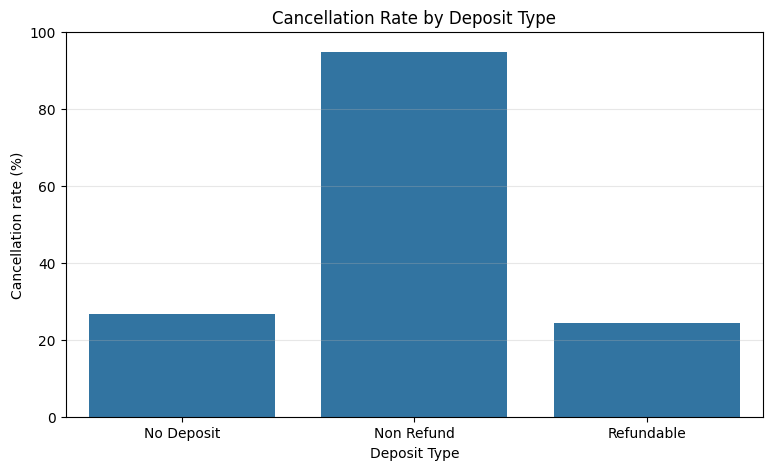

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=deposit_analysis,
    x="deposit_type",
    y="cancellation_rate"
)

plt.xlabel("Deposit Type")
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation Rate by Deposit Type")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [48]:
segment_analysis = (
    df_clean
    .groupby("market_segment")
    .agg(
        bookings=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

segment_analysis["cancellation_rate"] = (
    segment_analysis["cancellation_rate"] * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    "cancellation_rate",
    ascending=False
)

segment_analysis

,market_segment,bookings,cancellation_rate
7,Undefined,2,100.00
6,Online TA,51370,35.37
4,Groups,4922,27.06
0,Aviation,226,19.91
5,Offline TA/TO,13852,14.84
3,Direct,11751,14.72
1,Complementary,688,12.21
2,Corporate,4200,12.12


Online TA имеет 51 370 бронирований и cancellation rate 35.37%. Undefined = 100% не используем как серьёзный вывод, потому что там всего 2 бронирования.

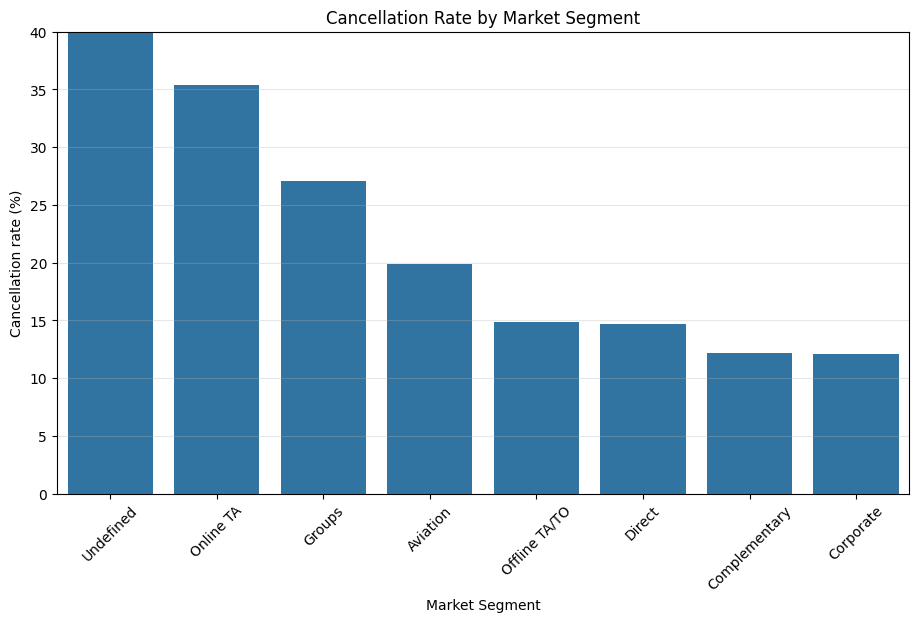

In [49]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=segment_analysis,
    x="market_segment",
    y="cancellation_rate"
)

plt.xlabel("Market Segment")
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation Rate by Market Segment")

plt.xticks(rotation=45)
plt.ylim(0, 40)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [50]:
repeat_analysis = (
    df_clean
    .groupby("is_repeated_guest")
    .agg(
        bookings=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

repeat_analysis["guest_type"] = repeat_analysis["is_repeated_guest"].map({
    0: "New Guest",
    1: "Repeated Guest"
})

repeat_analysis["cancellation_rate"] = (
    repeat_analysis["cancellation_rate"] * 100
).round(2)

repeat_analysis

,is_repeated_guest,bookings,cancellation_rate,guest_type
0,0,83648,28.29,New Guest
1,1,3363,7.73,Repeated Guest


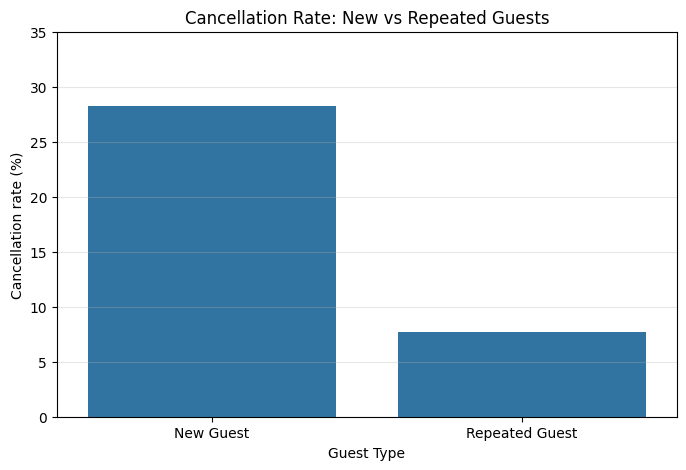

In [51]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=repeat_analysis,
    x="guest_type",
    y="cancellation_rate"
)

plt.xlabel("Guest Type")
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation Rate: New vs Repeated Guests")

plt.ylim(0, 35)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [52]:
country_analysis = (
    df_clean["country"]
    .value_counts()
    .head(15)
    .reset_index()
)

country_analysis.columns = ["country", "bookings"]

country_analysis

,country,bookings
0,PRT,27312
1,GBR,10409
2,FRA,8798
3,ESP,7230
4,DEU,5372
5,ITA,3052
6,IRL,3011
7,BEL,2065
8,BRA,1983
9,NLD,1901


Спрос в исследуемом датасете имеет выраженную географическую концентрацию: наибольшее количество бронирований приходится на клиентов из Portugal, далее следуют United Kingdom, France, Spain и Germany

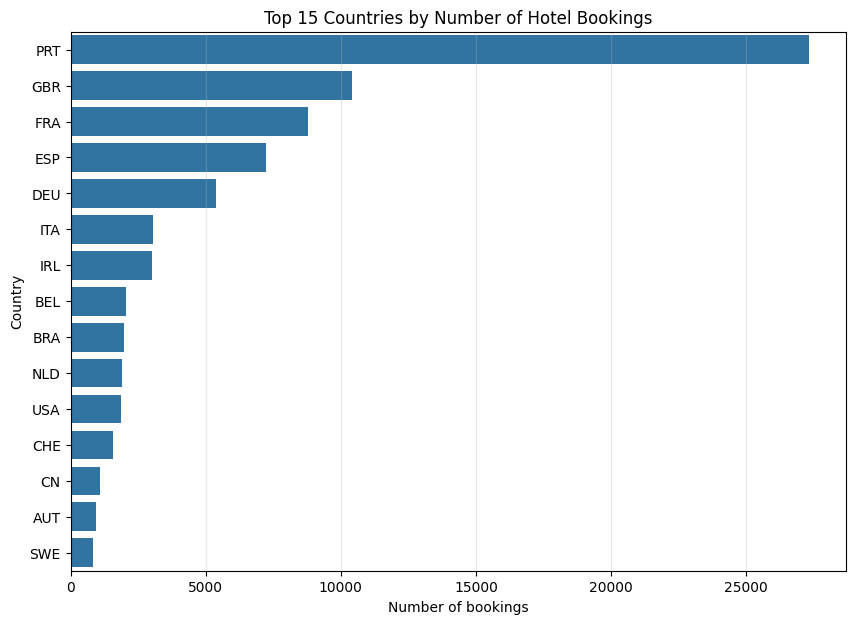

In [53]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=country_analysis,
    y="country",
    x="bookings"
)

plt.xlabel("Number of bookings")
plt.ylabel("Country")
plt.title("Top 15 Countries by Number of Hotel Bookings")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [54]:
import sqlite3

conn = sqlite3.connect("hotel_booking.db")

df_clean.to_sql(
    "hotel_bookings",
    conn,
    if_exists="replace",
    index=False
)

print("Table created successfully!")

Table created successfully!


In [55]:
query = """
SELECT COUNT(*) AS total_bookings
FROM hotel_bookings;
"""

pd.read_sql_query(query, conn)

,total_bookings
0,87011


In [56]:
query = """
SELECT
    hotel,
    COUNT(*) AS bookings,
    SUM(is_canceled) AS cancellations,
    ROUND(AVG(adr), 2) AS avg_adr,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate
FROM hotel_bookings
GROUP BY hotel
ORDER BY bookings DESC;
"""

hotel_sql = pd.read_sql_query(query, conn)

hotel_sql

,hotel,bookings,cancellations,avg_adr,cancellation_rate
0,City Hotel,53055,15954,111.40,30.07
1,Resort Hotel,33956,7974,99.06,23.48


In [57]:
df_clean.to_sql(
    "hotel_bookings",
    conn,
    if_exists="replace",
    index=False
)

87011

In [58]:
query = """
SELECT
    arrival_month_num,
    hotel,
    COUNT(*) AS bookings,
    ROUND(AVG(adr), 2) AS avg_adr
FROM hotel_bookings
GROUP BY arrival_month_num, hotel
ORDER BY arrival_month_num, hotel;
"""

monthly_sql = pd.read_sql_query(query, conn)

monthly_sql

,arrival_month_num,hotel,bookings,avg_adr
0,1,City Hotel,2706,85.52
1,1,Resort Hotel,1961,49.18
2,2,City Hotel,3573,89.37
3,2,Resort Hotel,2492,54.10
4,3,City Hotel,4817,95.26
5,3,Resort Hotel,2656,57.59
6,4,City Hotel,5051,117.44
7,4,Resort Hotel,2828,79.28
8,5,City Hotel,5387,128.09
9,5,Resort Hotel,2942,80.55


In [59]:
query = """
SELECT
    CASE
        WHEN lead_time <= 7 THEN '0-7 days'
        WHEN lead_time <= 30 THEN '8-30 days'
        WHEN lead_time <= 90 THEN '31-90 days'
        WHEN lead_time <= 180 THEN '91-180 days'
        ELSE '181+ days'
    END AS lead_time_group,

    COUNT(*) AS bookings,

    SUM(is_canceled) AS cancellations,

    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate

FROM hotel_bookings

GROUP BY lead_time_group

ORDER BY
    CASE lead_time_group
        WHEN '0-7 days' THEN 1
        WHEN '8-30 days' THEN 2
        WHEN '31-90 days' THEN 3
        WHEN '91-180 days' THEN 4
        WHEN '181+ days' THEN 5
    END;
"""

lead_time_sql = pd.read_sql_query(query, conn)

lead_time_sql

,lead_time_group,bookings,cancellations,cancellation_rate
0,0-7 days,18185,1530,8.41
1,8-30 days,16300,4134,25.36
2,31-90 days,22666,7264,32.05
3,91-180 days,18170,6360,35.00
4,181+ days,11690,4640,39.69


SQL-анализ подтвердил наличие выраженной связи между сроком предварительного бронирования и долей отмен. В исследуемых данных cancellation rate увеличивается с 8.41% для бронирований за 0–7 дней до 39.69% для бронирований за 181 день и более.

In [60]:
query = """
SELECT
    customer_type,
    COUNT(*) AS bookings,
    SUM(is_canceled) AS cancellations,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate
FROM hotel_bookings
GROUP BY customer_type
ORDER BY cancellation_rate DESC;
"""

customer_sql = pd.read_sql_query(query, conn)

customer_sql

,customer_type,bookings,cancellations,cancellation_rate
0,Transient,71726,21604,30.12
1,Contract,3134,512,16.34
2,Transient-Party,11611,1759,15.15
3,Group,540,53,9.81


Cancellation rate различается между типами клиентов. Наиболее высокая доля отмен наблюдается среди Transient-клиентов (30.12%), тогда как среди Group-клиентов она составляет 9.81%. При интерпретации результатов учитывается различный размер клиентских групп.

In [61]:
query = """
SELECT
    distribution_channel,
    COUNT(*) AS bookings,
    SUM(is_canceled) AS cancellations,
    ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate,
    ROUND(AVG(adr), 2) AS avg_adr
FROM hotel_bookings
GROUP BY distribution_channel
ORDER BY bookings DESC;
"""

channel_sql = pd.read_sql_query(query, conn)

channel_sql

,distribution_channel,bookings,cancellations,cancellation_rate,avg_adr
0,TA/TO,68842,21327,30.98,108.77
1,Direct,12921,1915,14.82,109.56
2,Corporate,5062,646,12.76,68.77
3,GDS,181,36,19.89,120.32
4,Undefined,5,4,80.00,46.24


Основной объём бронирований в исследуемых данных приходится на канал TA/TO (68 842 бронирования). При этом его cancellation rate составляет 30.98%, что выше показателей Direct (14.82%) и Corporate (12.76%).

In [62]:
df_clean.to_csv("hotel_bookings_clean.csv", index=False)

print("File saved:", df_clean.shape)

File saved: (87011, 39)


In [63]:
from google.colab import files
files.download("hotel_bookings_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>